In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, 
                             ConfusionMatrixDisplay, roc_curve, auc,
                             classification_report)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [4]:
df = pd.read_csv('data/heart_disease_uci.csv')

print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nFirst 5 Rows:")
df.head()

Shape: (920, 16)

Column Names:
 ['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

First 5 Rows:


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [6]:
# See exact column names in your dataset
print(df.columns.tolist())

# Rename 'num' to 'target'
df = df.rename(columns={'num': 'target'})

# Make it binary (0 = no disease, 1 = disease)
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

print("\n✅ Fixed! Target column distribution:")
print(df['target'].value_counts())

['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

✅ Fixed! Target column distribution:
target
1    509
0    411
Name: count, dtype: int64


In [7]:
# Check for missing values
missing = df.isnull().sum()
print("Missing values per column:\n", missing)

# Drop duplicates if any
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"\nRemoved {before - after} duplicate rows")

# Handle missing values — fill numeric columns with median
for col in df.select_dtypes(include=[np.number]).columns:
    df[col].fillna(df[col].median(), inplace=True)

# Handle categorical columns with mode
for col in df.select_dtypes(include=['object']).columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Encode any text/categorical columns to numbers
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

print("\n✅ Data cleaned successfully!")
print("Final shape:", df.shape)
df.head()

Missing values per column:
 id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
target        0
dtype: int64

Removed 0 duplicate rows

✅ Data cleaned successfully!
Final shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
0,1,63,1,0,3,145.0,233.0,1,0,150.0,0,2.3,0,0.0,0,0
1,2,67,1,0,0,160.0,286.0,0,0,108.0,1,1.5,1,3.0,1,1
2,3,67,1,0,0,120.0,229.0,0,0,129.0,1,2.6,1,2.0,2,1
3,4,37,1,0,2,130.0,250.0,0,1,187.0,0,3.5,0,0.0,1,0
4,5,41,0,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0.0,1,0


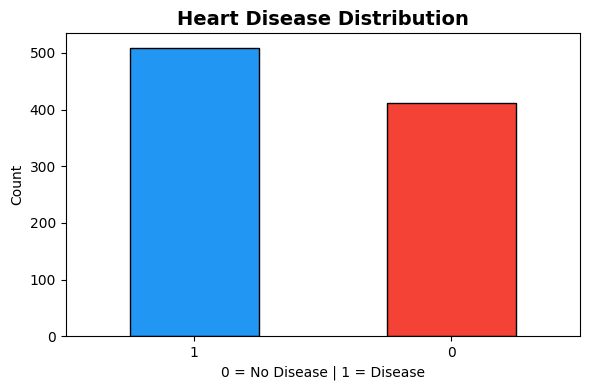

No Disease: 411
Has Disease: 509


In [8]:
plt.figure(figsize=(6, 4))
colors = ['#2196F3', '#F44336']
df['target'].value_counts().plot(kind='bar', color=colors, edgecolor='black')
plt.title('Heart Disease Distribution', fontsize=14, fontweight='bold')
plt.xlabel('0 = No Disease | 1 = Disease')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("No Disease:", df['target'].value_counts()[0])
print("Has Disease:", df['target'].value_counts()[1])

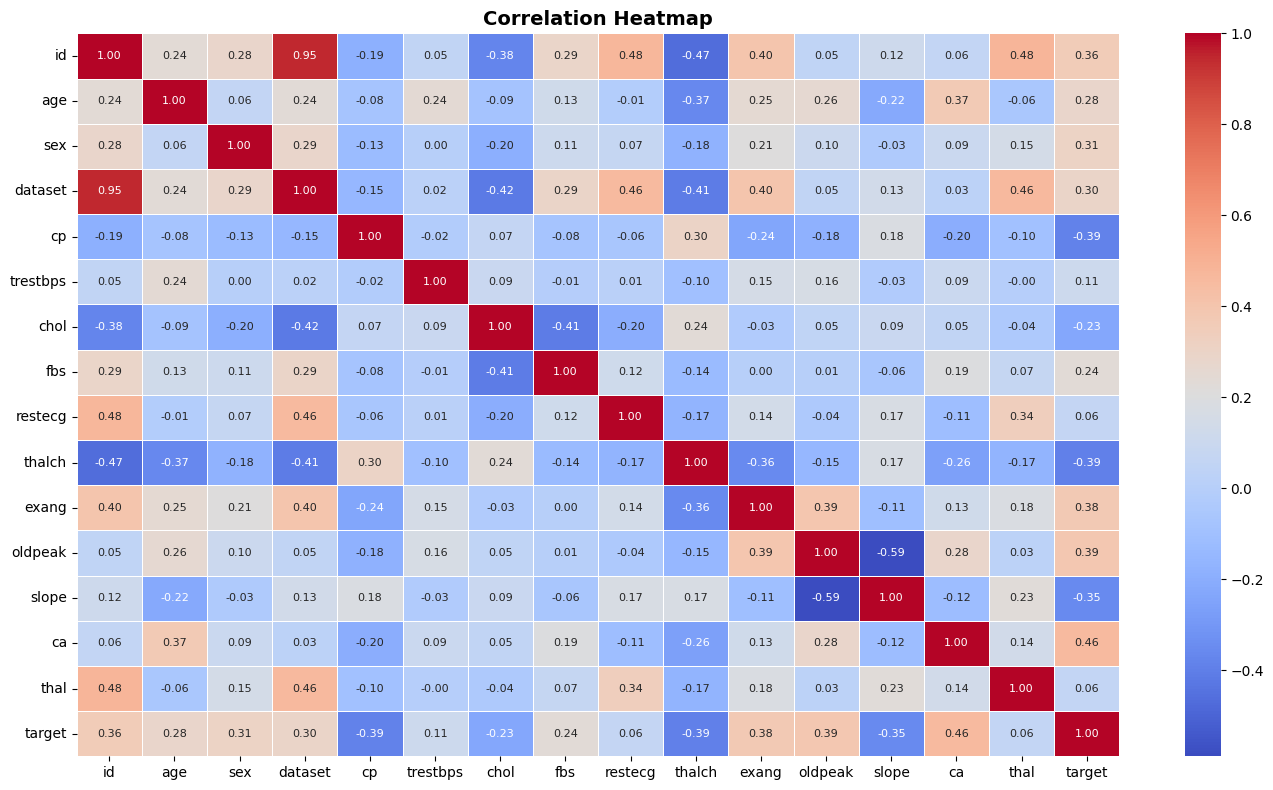

In [9]:
plt.figure(figsize=(14, 8))
correlation = df.corr()
sns.heatmap(correlation, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


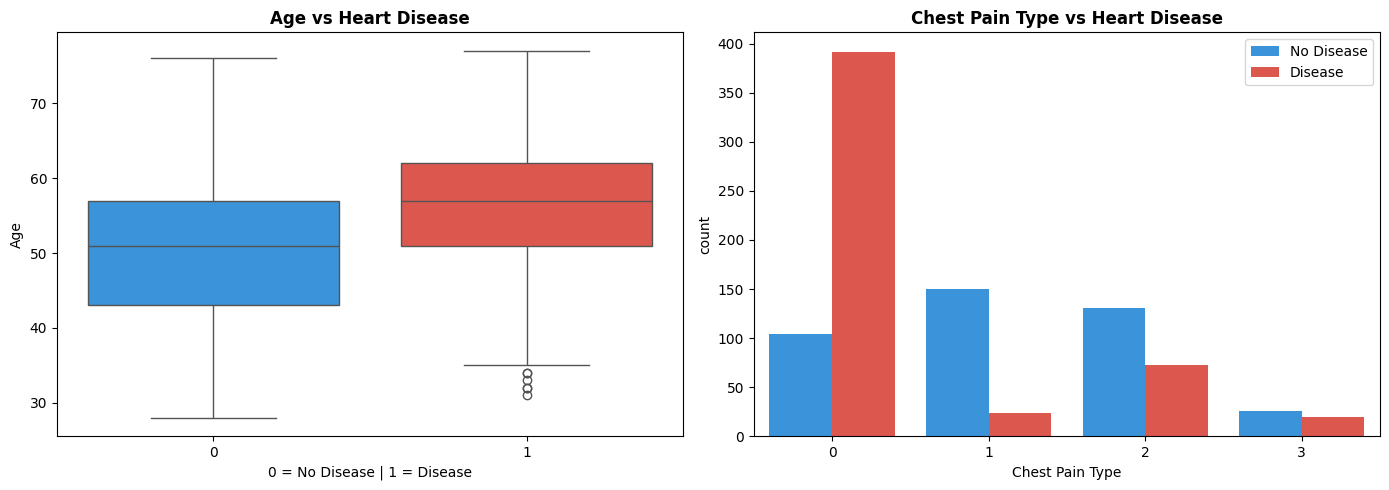

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution by target
sns.boxplot(data=df, x='target', y='age', 
            palette=['#2196F3','#F44336'], ax=axes[0])
axes[0].set_title('Age vs Heart Disease', fontweight='bold')
axes[0].set_xlabel('0 = No Disease | 1 = Disease')
axes[0].set_ylabel('Age')

# Chest pain type vs target
sns.countplot(data=df, x='cp', hue='target',
              palette=['#2196F3','#F44336'], ax=axes[1])
axes[1].set_title('Chest Pain Type vs Heart Disease', fontweight='bold')
axes[1].set_xlabel('Chest Pain Type')
axes[1].legend(['No Disease', 'Disease'])

plt.tight_layout()
plt.show()

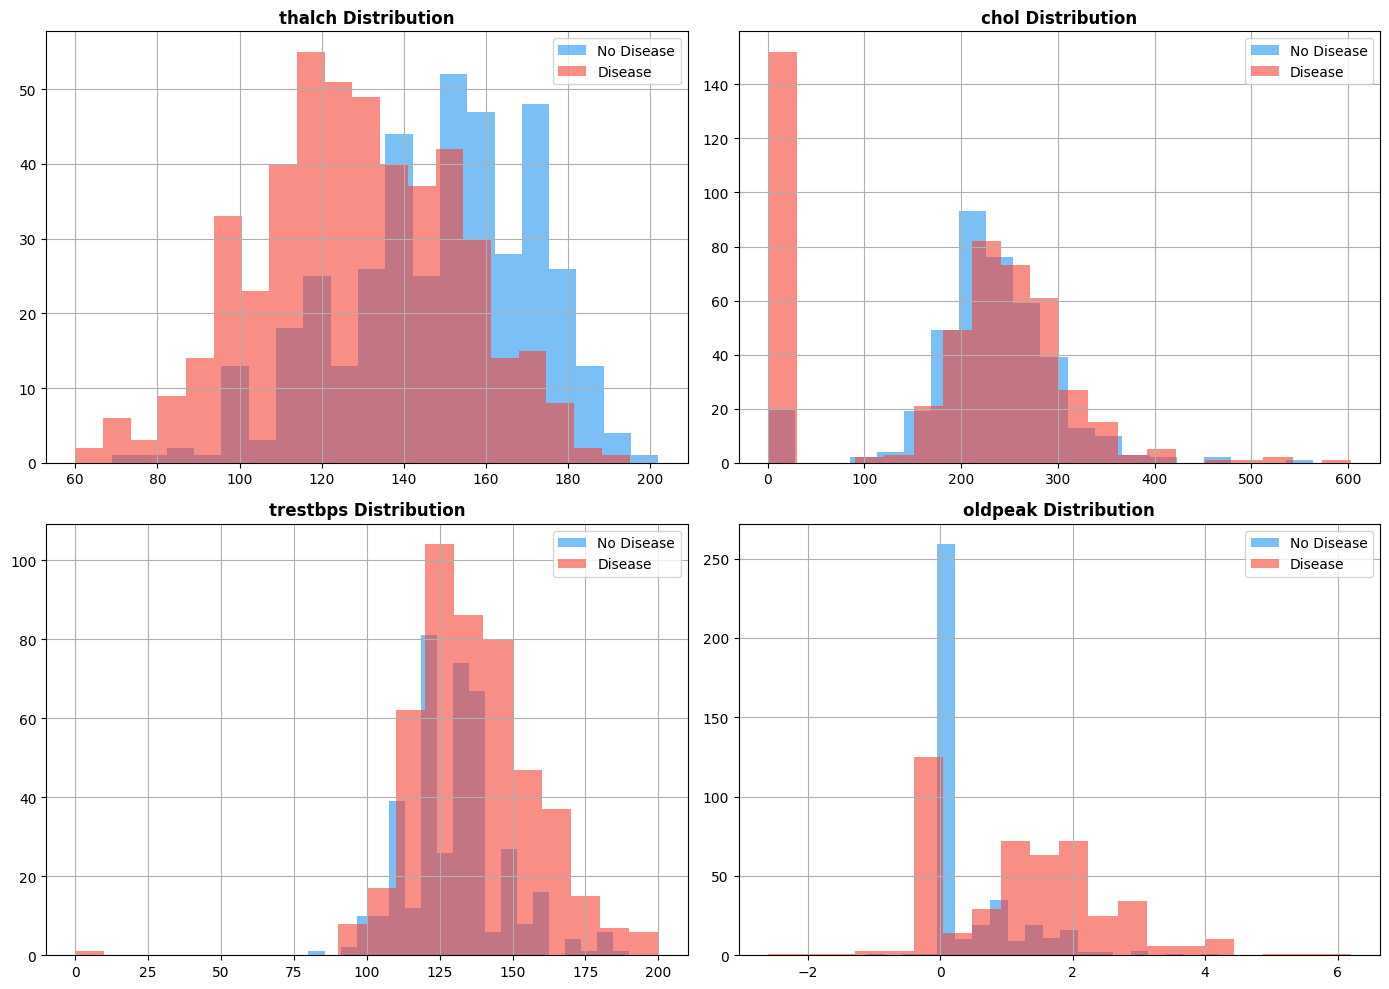

In [11]:
features = ['thalch', 'chol', 'trestbps', 'oldpeak']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    if feature in df.columns:
        df[df['target']==0][feature].hist(ax=axes[i], alpha=0.6, 
                                           color='#2196F3', label='No Disease', bins=20)
        df[df['target']==1][feature].hist(ax=axes[i], alpha=0.6, 
                                           color='#F44336', label='Disease', bins=20)
        axes[i].set_title(f'{feature} Distribution', fontweight='bold')
        axes[i].legend()

plt.tight_layout()
plt.show()

In [13]:
# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✅ Data split complete!")
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")
print(f"Features         : {X_train.shape[1]}")

✅ Data split complete!
Training samples : 736
Testing  samples : 184
Features         : 15


In [15]:
from sklearn.impute import SimpleImputer

# Check which columns still have NaN
print("NaN values before fix:")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

# Fix NaN values using median imputation
imputer = SimpleImputer(strategy='median')

X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test  = pd.DataFrame(imputer.transform(X_test),      columns=X_test.columns)

print("\n✅ NaN values after fix:")
print(X_train.isnull().sum().sum(), "missing values remaining")

NaN values before fix:
trestbps     45
chol         25
thalch       42
oldpeak      45
ca          486
dtype: int64

✅ NaN values after fix:
0 missing values remaining


In [16]:
# Model 1: Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

# Model 2: Decision Tree
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

print("=" * 35)
print(f"  Logistic Regression Accuracy : {lr_acc*100:.2f}%")
print(f"  Decision Tree Accuracy       : {dt_acc*100:.2f}%")
print("=" * 35)
print(f"\n🏆 Better model: {'Logistic Regression' if lr_acc >= dt_acc else 'Decision Tree'}")

  Logistic Regression Accuracy : 82.07%
  Decision Tree Accuracy       : 84.24%

🏆 Better model: Decision Tree


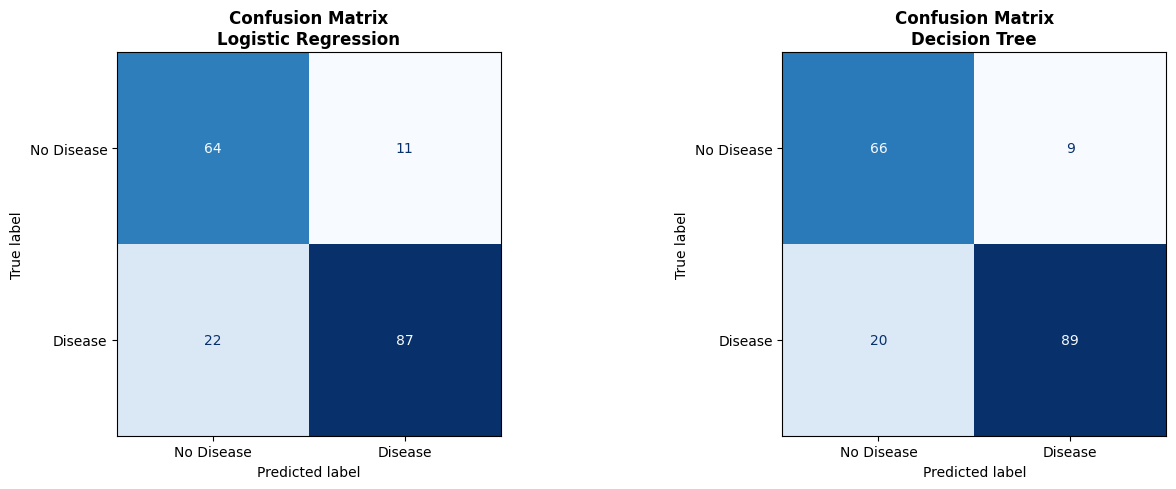


=== Classification Report (Logistic Regression) ===
              precision    recall  f1-score   support

  No Disease       0.74      0.85      0.80        75
     Disease       0.89      0.80      0.84       109

    accuracy                           0.82       184
   macro avg       0.82      0.83      0.82       184
weighted avg       0.83      0.82      0.82       184



In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, pred, name in zip(
    axes,
    [lr_model, dt_model],
    [lr_pred, dt_pred],
    ['Logistic Regression', 'Decision Tree']
):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                   display_labels=['No Disease', 'Disease'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix\n{name}', fontweight='bold')

plt.tight_layout()
plt.show()

# Detailed report for best model
print("\n=== Classification Report (Logistic Regression) ===")
print(classification_report(y_test, lr_pred, 
      target_names=['No Disease', 'Disease']))

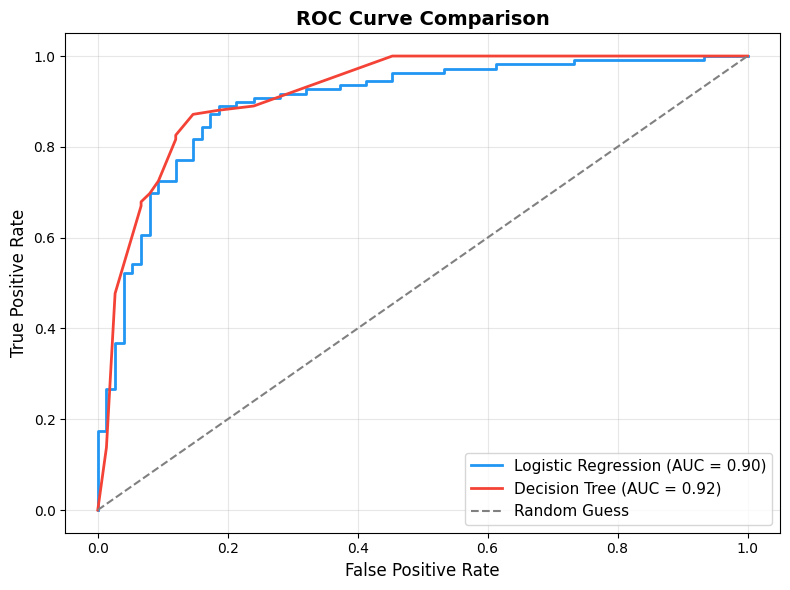

In [18]:
plt.figure(figsize=(8, 6))

for model, name, color in zip(
    [lr_model, dt_model],
    ['Logistic Regression', 'Decision Tree'],
    ['#2196F3', '#F44336']
):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0,1],[0,1],'--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

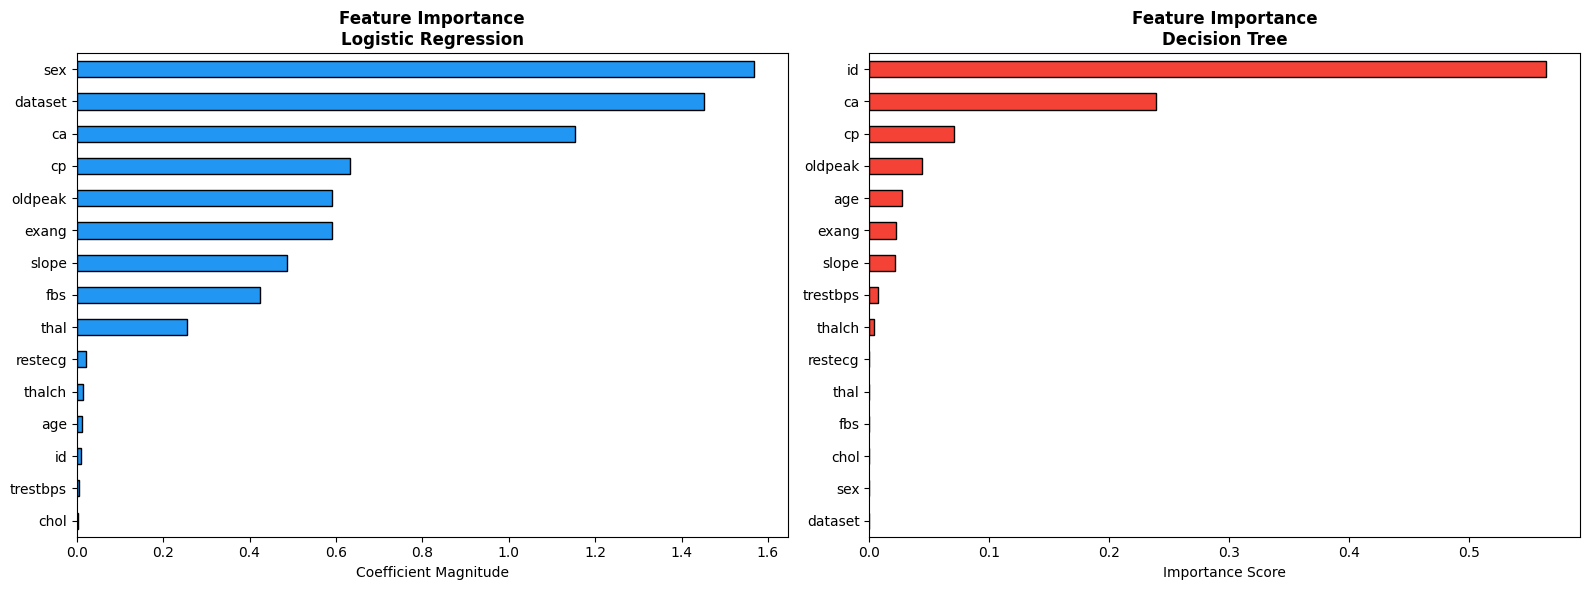


🔑 Top 3 Most Important Features (Decision Tree):
id    0.564293
ca    0.238983
cp    0.070291
dtype: float64


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Logistic Regression — coefficient magnitude
lr_importance = pd.Series(
    np.abs(lr_model.coef_[0]), index=X.columns
).sort_values(ascending=True)

lr_importance.plot(kind='barh', ax=axes[0], 
                   color='#2196F3', edgecolor='black')
axes[0].set_title('Feature Importance\nLogistic Regression', 
                   fontweight='bold')
axes[0].set_xlabel('Coefficient Magnitude')

# Decision Tree — feature importances
dt_importance = pd.Series(
    dt_model.feature_importances_, index=X.columns
).sort_values(ascending=True)

dt_importance.plot(kind='barh', ax=axes[1], 
                   color='#F44336', edgecolor='black')
axes[1].set_title('Feature Importance\nDecision Tree', 
                   fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

print("\n🔑 Top 3 Most Important Features (Decision Tree):")
print(dt_importance.sort_values(ascending=False).head(3))

In [20]:
print("=" * 45)
print("       HEART DISEASE PREDICTION SUMMARY")
print("=" * 45)
print(f"  Dataset shape          : {df.shape}")
print(f"  Training samples       : {X_train.shape[0]}")
print(f"  Testing samples        : {X_test.shape[0]}")
print(f"  Features used          : {X.shape[1]}")
print("-" * 45)
print(f"  Logistic Regression    : {lr_acc*100:.2f}% accuracy")
print(f"  Decision Tree          : {dt_acc*100:.2f}% accuracy")
print("-" * 45)
top_feature = dt_importance.sort_values(ascending=False).index[0]
print(f"  Most important feature : {top_feature}")
print("=" * 45)
print("✅ Project Complete!")

       HEART DISEASE PREDICTION SUMMARY
  Dataset shape          : (920, 16)
  Training samples       : 736
  Testing samples        : 184
  Features used          : 15
---------------------------------------------
  Logistic Regression    : 82.07% accuracy
  Decision Tree          : 84.24% accuracy
---------------------------------------------
  Most important feature : id
✅ Project Complete!
